In [9]:
from rsm3d.rsm3d import RSMBuilder


spec_file = "/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/setup_6oct23"
tiff_dir  = "/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/data_6oct23_tiff"
use_dask  = False  # Set to True if you want to use Dask for parallel processing

builder = RSMBuilder(
    spec_file, tiff_dir,
    selected_scans=(17,18,19),
    fourc_mode="ZXZ",            # or "ZYX" if your 4-circle uses Z–Y–X
    motor_map={"omega":"th", "chi":"chi", "phi":"phi"},
    ub_includes_2pi=True,        # set False if your UB is no-2π
    center_is_one_based=False
)
Q_samp, hkl, intensity = builder.compute_full()
print(hkl[1, 257, 515, 0])
# optional gridding in HKL (mean)
grid, (hax,kax,lax) = builder.regrid_xu(
    space="hkl", grid_shape=(256,256,256), stream=True, normalize="mean"
)
    # Create

# # print(hkl.max())
# from rsm3d.rsm3d import crop_by_positions
# Q_samp, hkl, intensity = crop_by_positions(Q_samp, hkl, intensity, (0, 122), (180, 510), (370, 620))
# rsm_q,   edges_q   = builder.regrid_auto(space='q',   grid_shape=(200, 200, 200), method='mean')
# rsm_hkl, edges_hkl = builder.regrid_auto(space='hkl', grid_shape=(200, 200, 200), method='mean')

0.0cessed 123/123 frames


/nsls2/users/xyang4/pyprojects/pyisr/.pixi/envs/default/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


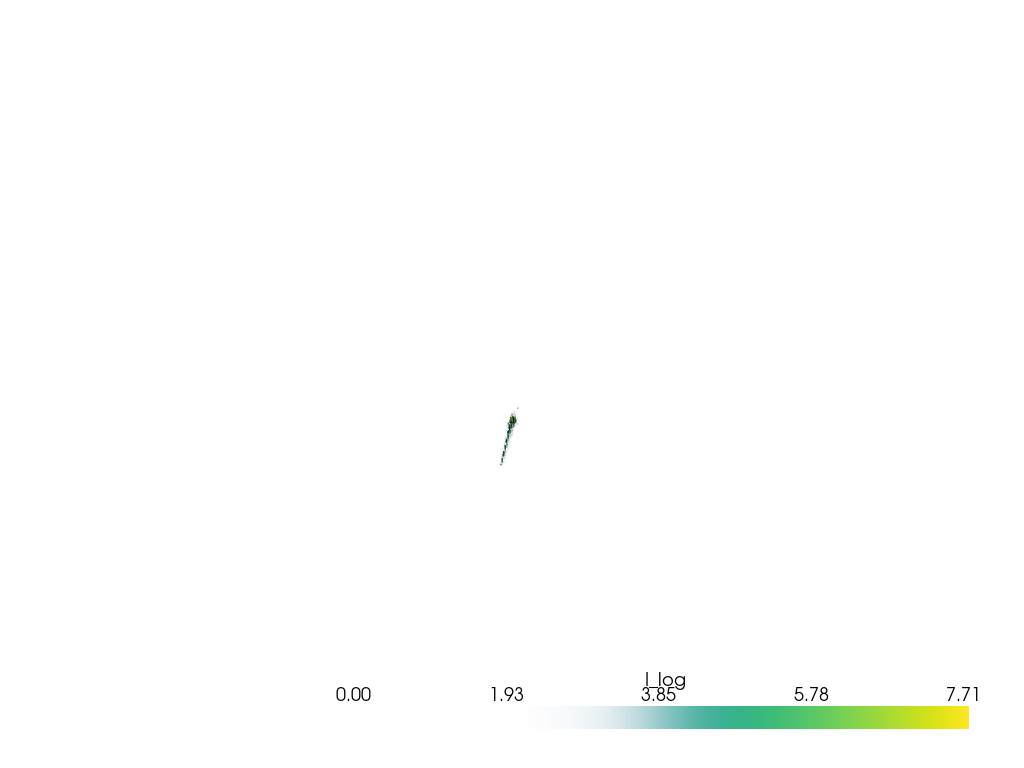

In [10]:


# 3) Export to VTK (rectilinear is safest)
import pyvista as pv, numpy as np
rg = pv.RectilinearGrid(hax, kax, lax)
rg["I_mean"] = grid.ravel(order="F")
rg["I_log"] = np.log1p(rg["I_mean"])
rg.save("rsm_hkl.vtr")

# 4) Preview (optional)
p = pv.Plotter()
p.add_volume(rg, scalars="I_log", opacity="sigmoid", cmap="viridis", shade=True)
p.show()

In [2]:
# After compute_full()
rsm_interp, grid_axes = builder.regrid_interpolate(space='hkl', grid_shape=(200,200,200), method='linear')

In [3]:
from rsm3d.data_io import write_rsm_volume_to_vtk
write_rsm_volume_to_vtk(rsm_interp, grid_axes, '/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/rsm3d_hkl_interp.vtk', binary=False)

In [4]:
from rsm3d.data_io import write_rsm_volume_to_vtk
write_rsm_volume_to_vtk(rsm_hkl, edges_hkl, '/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/rsm3d_hkl_200.vtk', binary=False)

In [11]:
import numpy as np
from pathlib import Path

# If your class file is elsewhere, update this import:
from rsm3d.rsm3d import RSMBuilder  # <-- 4-circle xrayutilities builder

def ensure_axis_ascending(grid, axes):
    """
    Make x/y/z axes strictly ascending for ParaView; flip grid dims to match.
    grid: (nx, ny, nz)
    axes: (xax, yax, zax)
    returns: (grid_fixed, (xax_fixed, yax_fixed, zax_fixed))
    """
    x, y, z = [np.asarray(a) for a in axes]
    G = grid
    if len(x) > 1 and x[1] < x[0]:
        x = x[::-1]; G = G[::-1, :, :]
    if len(y) > 1 and y[1] < y[0]:
        y = y[::-1]; G = G[:, ::-1, :]
    if len(z) > 1 and z[1] < z[0]:
        z = z[::-1]; G = G[:, :, ::-1]
    return G, (x, y, z)

def write_vtr_rectilinear(filename, grid, axes, arrays=None, dtype="Float32"):
    """
    Minimal VTK XML RectilinearGrid (.vtr) writer in ASCII (no external deps).
    - filename: path to write
    - grid: (nx, ny, nz) array (point data)
    - axes: (xax, yax, zax) 1D arrays of coords (len nx, ny, nz)
    - arrays: dict of extra point-data name -> ndarray (same shape as grid)
      If None, writes two arrays: 'I' (grid) and 'I_log' (log1p grid).
    - dtype: 'Float32' or 'Float64' (controls on-disk type)
    
    NOTE: VTK’s point-order for rectilinear grids is X fastest, then Y, then Z.
          So we flatten with order='C'.
    """
    xax, yax, zax = [np.asarray(a) for a in axes]
    nx, ny, nz = len(xax), len(yax), len(zax)
    # sanity
    if grid.shape != (nx, ny, nz):
        raise ValueError(f"grid shape {grid.shape} != ({nx},{ny},{nz}) from axes lengths")
    # default arrays
    if arrays is None:
        arrays = {}
        arrays["I"] = np.asarray(grid)
        arrays["I_log"] = np.log1p(np.maximum(arrays["I"], 0.0))
    # XML header
    header = (
        f'<?xml version="1.0"?>\n'
        f'<VTKFile type="RectilinearGrid" version="0.1" byte_order="LittleEndian">\n'
        f'  <RectilinearGrid WholeExtent="0 {nx-1} 0 {ny-1} 0 {nz-1}">\n'
        f'    <Piece Extent="0 {nx-1} 0 {ny-1} 0 {nz-1}">\n'
        f'      <PointData Scalars="I">\n'
    )
    # point-data arrays
    pd = []
    for name, arr in arrays.items():
        arr = np.asarray(arr)
        if arr.shape != (nx, ny, nz):
            raise ValueError(f"PointData '{name}' shape {arr.shape} != grid shape {(nx,ny,nz)}")
        data_str = " ".join(map(str, arr.ravel(order="C")))
        pd.append(f'        <DataArray type="{dtype}" Name="{name}" format="ascii">\n          {data_str}\n        </DataArray>\n')
    pd = "".join(pd)
    # coords
    x_str = " ".join(map(str, xax))
    y_str = " ".join(map(str, yax))
    z_str = " ".join(map(str, zax))
    coords = (
        f'      </PointData>\n'
        f'      <CellData/>\n'
        f'      <Coordinates>\n'
        f'        <DataArray type="{dtype}" Name="X Coordinates" format="ascii">\n          {x_str}\n        </DataArray>\n'
        f'        <DataArray type="{dtype}" Name="Y Coordinates" format="ascii">\n          {y_str}\n        </DataArray>\n'
        f'        <DataArray type="{dtype}" Name="Z Coordinates" format="ascii">\n          {z_str}\n        </DataArray>\n'
        f'      </Coordinates>\n'
        f'    </Piece>\n'
        f'  </RectilinearGrid>\n'
        f'</VTKFile>\n'
    )
    Path(filename).write_text(header + pd + coords)
    return str(filename)

In [12]:
# USER INPUTS

spec_file = "/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/setup_6oct23"
tiff_dir  = "/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/data_6oct23_tiff"
scan_list = (17, 18, 19)     # any list/tuple of scan numbers
out_vtr   = "/nsls2/data/staff/xyang4/data_cs/isr_rsm3d/rsm_hkl.vtr"    # output file

# Build with 4-circle (ZXZ: φ(Z) → χ(X) → ω(Z))
builder = RSMBuilder(
    spec_file, tiff_dir,
    selected_scans=scan_list,
    ub_includes_2pi=True,        # set False if your UB is "no-2π"
    center_is_one_based=False,   # True if SPEC xcenter/ycenter are 1-based
    fourc_mode="ZXZ",            # or "ZYX" if your instrument uses Z-Y-X
    motor_map={"omega":"th", "chi":"chi", "phi":"phi"},  # map to your SPEC columns
)

# Compute per-pixel Q & HKL
Q_samp, hkl, intensity = builder.compute_full()

# Regrid with xrayutilities gridder (mean or sum)
grid, (xax, yax, zax) = builder.regrid_xu(
    space="hkl",                 # "hkl" or "q"
    grid_shape=(256, 256, 256),  # adjust to taste / memory
    ranges=None,                 # or ((xmin,xmax),(ymin,ymax),(zmin,zmax)) to lock axes
    fuzzy=False,                 # True → FuzzyGridder3D; add width=... for footprint
    normalize="mean",            # "mean" or "sum"
    stream=True                  # frame-by-frame accumulation (RAM friendly)
)
grid.shape, len(xax), len(yax), len(zax)

((256, 256, 256), 256, 256, 256)

In [13]:
# Make axes strictly ascending (ParaView prefers this); flips grid dims as needed
grid2, axes2 = ensure_axis_ascending(grid, (xax, yax, zax))

# Optional: add more arrays (e.g., a clipped version)
arrays = {
    "I_mean": grid2,
    "I_log":  np.log1p(np.maximum(grid2, 0.0)),
}

# Write RectilinearGrid .vtr (ASCII)
vtr_path = write_vtr_rectilinear(out_vtr, grid2, axes2, arrays=arrays, dtype="Float32")
print(f"Wrote {vtr_path}")

Wrote /nsls2/data/staff/xyang4/data_cs/isr_rsm3d/rsm_hkl.vtr


/nsls2/users/xyang4/pyprojects/pyisr/.pixi/envs/default/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


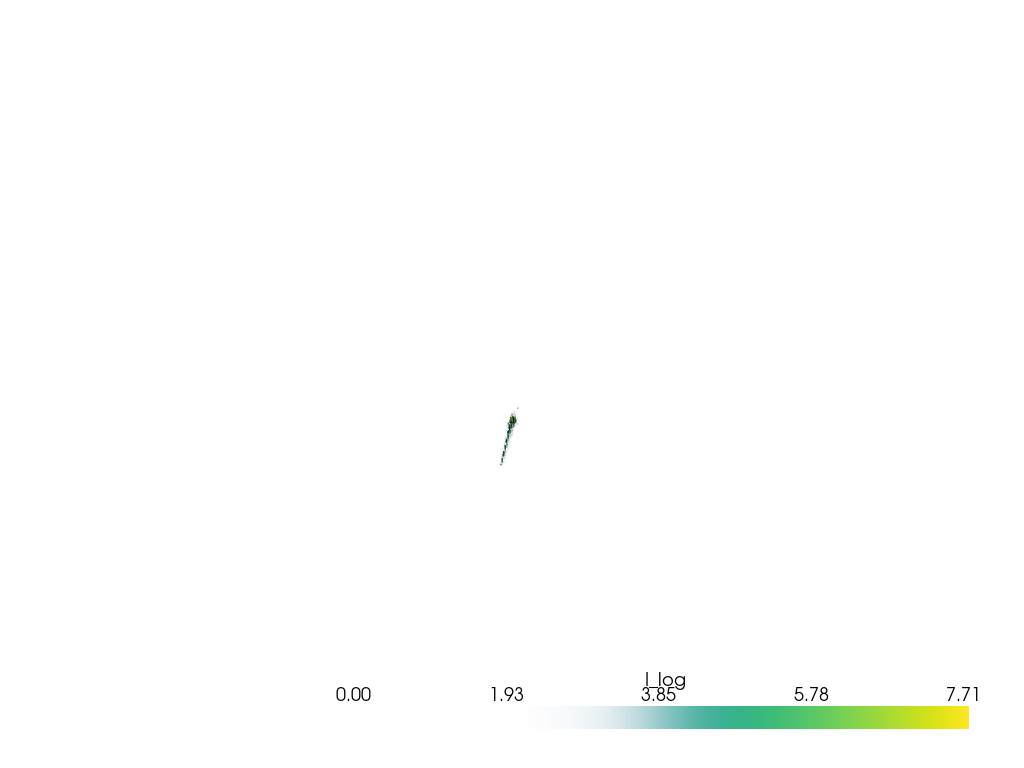

In [8]:
# Only if you have PyVista installed (pip install pyvista)
import pyvista as pv

xax2, yax2, zax2 = axes2
rg = pv.RectilinearGrid(xax2, yax2, zax2)
rg["I_log"] = arrays["I_log"].ravel(order="F")  # PyVista expects Fortran order for point data

p = pv.Plotter()
p.add_volume(rg, scalars="I_log", opacity="sigmoid", cmap="viridis", shade=True)
p.show()